# K-Means Parallèle sur CPU Benchmark

## Objectif

Comparer les performances des deux implémentations :
- **Version NumPy** : séquentielle, baseline
- **Version C++ OpenMP** : parallèle

Le benchmark suit la méthodologie du cours :
- `measure_time` pour des mesures répétées
- Courbes log-log temps vs taille n
- Variables : taille n, dimensionnalité d, nombre de clusters K

In [2]:
import sys, os, time
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs

from kmeans_numpy    import kmeans_numpy
from kmeans_parallel import kmeans_parallel

def measure_time(func, *args, repeat=5, **kwargs):
    """Mesure le temps moyen d'exécution sur `repeat` appels.
    Inspiré de teachcompute.ext_test_case.measure_time"""
    times = []
    for _ in range(repeat):
        t0 = time.perf_counter()
        func(*args, **kwargs)
        times.append(time.perf_counter() - t0)
    return {
        "average"   : np.mean(times),
        "min_exec"  : np.min(times),
        "max_exec"  : np.max(times),
        "deviation" : np.std(times),
    }

## Benchmark 1 

On fait varier le nombre de points n et on mesure le temps total d'une exécution K-Means complète (jusqu'à convergence).

In [3]:
# Paramètres fixes
K  = 8
d  = 10
ns = [500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000]

print(f"K={K}, d={d}, max_iter=100")
print(f"Tailles testées : {ns}")
print("Mesure en cours...\n")

obs = []
for n in ns:
    X, _ = make_blobs(n_samples=n, centers=K, n_features=d,
                      random_state=42)
    X = X.astype(np.float32)

    t_np  = measure_time(kmeans_numpy,    X, K, seed=42, repeat=3)
    t_par = measure_time(kmeans_parallel, X, K, seed=42, repeat=3)

    obs.append({
        "n"          : n,
        "numpy"      : t_np["average"],
        "parallel"   : t_par["average"],
        "speedup"    : t_np["average"] / t_par["average"],
    })
    print(f"n={n:6d} | numpy={t_np['average']*1000:7.1f}ms "
          f"| parallel={t_par['average']*1000:7.1f}ms "
          f"| speedup={t_np['average']/t_par['average']:.2f}x")

df = pd.DataFrame(obs)
print("\n", df.to_string(index=False))

K=8, d=10, max_iter=100
Tailles testées : [500, 1000, 2000, 5000, 10000, 20000, 50000]
Mesure en cours...

n=   500 | numpy=    0.8ms | parallel=    1.0ms | speedup=0.84x
n=  1000 | numpy=    0.9ms | parallel=    0.3ms | speedup=2.92x
n=  2000 | numpy=    3.1ms | parallel=    0.6ms | speedup=5.41x
n=  5000 | numpy=    3.0ms | parallel=    0.4ms | speedup=8.48x
n= 10000 | numpy=   46.5ms | parallel=    2.8ms | speedup=16.83x
n= 20000 | numpy=  194.2ms | parallel=    7.0ms | speedup=27.75x
n= 50000 | numpy=  719.6ms | parallel=   23.1ms | speedup=31.09x

     n    numpy  parallel   speedup
  500 0.000836  0.000999  0.836413
 1000 0.000896  0.000307  2.915894
 2000 0.003086  0.000571  5.409641
 5000 0.003048  0.000359  8.483443
10000 0.046529  0.002765 16.825640
20000 0.194164  0.006998 27.745770
50000 0.719559  0.023147 31.086198


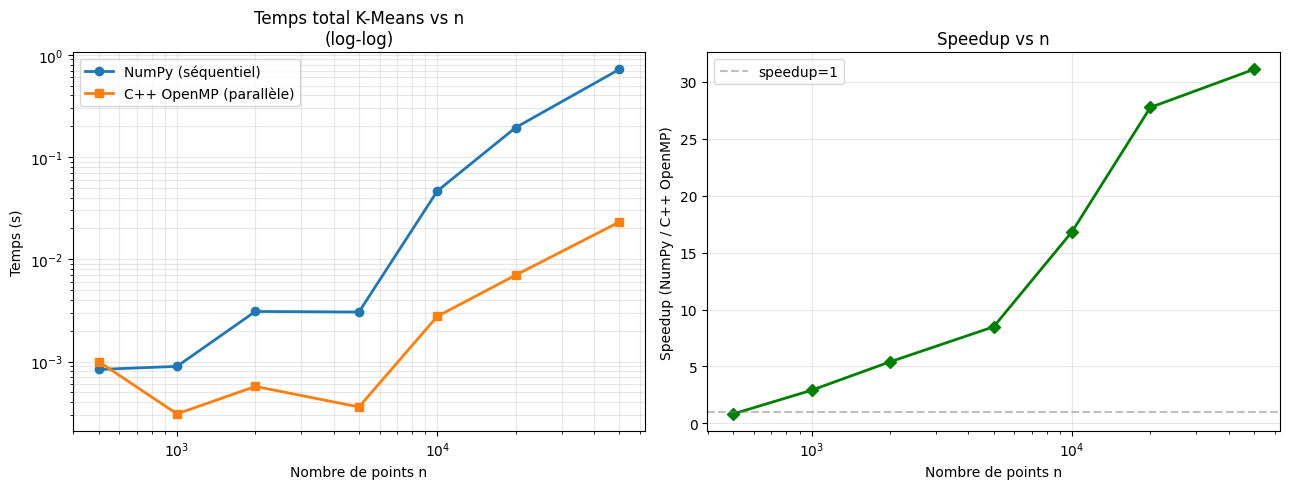

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graphe 1 : temps absolu (log-log)
ax = axes[0]
ax.loglog(df["n"], df["numpy"],    "o-", label="NumPy (séquentiel)",   linewidth=2)
ax.loglog(df["n"], df["parallel"], "s-", label="C++ OpenMP (parallèle)", linewidth=2)
ax.set_xlabel("Nombre de points n")
ax.set_ylabel("Temps (s)")
ax.set_title("Temps total K-Means vs n\n(log-log)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

# Graphe 2 : speedup
ax = axes[1]
ax.semilogx(df["n"], df["speedup"], "D-", color="green", linewidth=2)
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5, label="speedup=1")
ax.set_xlabel("Nombre de points n")
ax.set_ylabel("Speedup (NumPy / C++ OpenMP)")
ax.set_title("Speedup vs n")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Benchmark 2: Temps vs dimensionnalité d

La dimensionnalité d influence directement le coût du calcul de distance (O(d) par paire point-centroïde).

In [5]:
# Paramètres fixes
n = 10_000
K = 8
ds = [2, 5, 10, 20, 50, 100, 200]

print(f"n={n}, K={K}")
print(f"Dimensions testées : {ds}\n")

obs_d = []
for d in ds:
    X, _ = make_blobs(n_samples=n, centers=K, n_features=d,
                      random_state=42)
    X = X.astype(np.float32)

    t_np  = measure_time(kmeans_numpy,    X, K, seed=42, repeat=3)
    t_par = measure_time(kmeans_parallel, X, K, seed=42, repeat=3)

    obs_d.append({
        "d"        : d,
        "numpy"    : t_np["average"],
        "parallel" : t_par["average"],
        "speedup"  : t_np["average"] / t_par["average"],
    })
    print(f"d={d:4d} | numpy={t_np['average']*1000:7.1f}ms "
          f"| parallel={t_par['average']*1000:7.1f}ms "
          f"| speedup={t_np['average']/t_par['average']:.2f}x")

df_d = pd.DataFrame(obs_d)

n=10000, K=8
Dimensions testées : [2, 5, 10, 20, 50, 100, 200]

d=   2 | numpy=   19.8ms | parallel=    1.2ms | speedup=16.40x
d=   5 | numpy=   32.9ms | parallel=    1.9ms | speedup=17.14x
d=  10 | numpy=   49.1ms | parallel=    2.8ms | speedup=17.72x
d=  20 | numpy=  111.2ms | parallel=    5.1ms | speedup=21.83x
d=  50 | numpy=    9.0ms | parallel=    0.7ms | speedup=12.25x
d= 100 | numpy=  339.5ms | parallel=    8.1ms | speedup=41.75x
d= 200 | numpy=   54.8ms | parallel=    1.2ms | speedup=44.11x


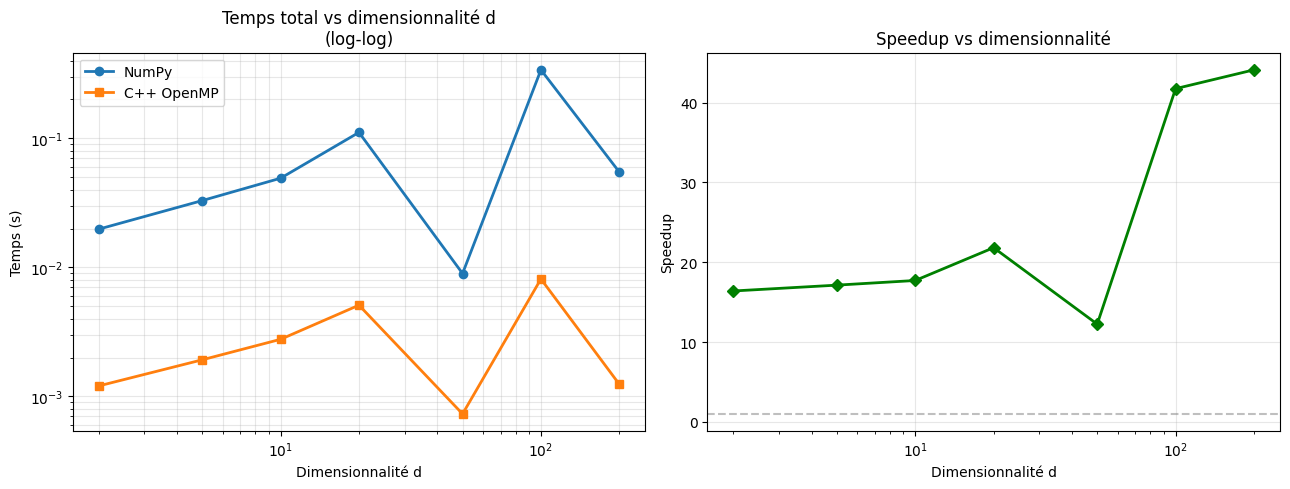

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.loglog(df_d["d"], df_d["numpy"],    "o-", label="NumPy",     linewidth=2)
ax.loglog(df_d["d"], df_d["parallel"], "s-", label="C++ OpenMP", linewidth=2)
ax.set_xlabel("Dimensionnalité d")
ax.set_ylabel("Temps (s)")
ax.set_title("Temps total vs dimensionnalité d\n(log-log)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
ax.semilogx(df_d["d"], df_d["speedup"], "D-", color="green", linewidth=2)
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Dimensionnalité d")
ax.set_ylabel("Speedup")
ax.set_title("Speedup vs dimensionnalité")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Tableau récapitulatif final
print("=== RÉCAPITULATIF BENCHMARK ===\n")
print("Benchmark 1 : Temps vs n (K=8, d=10)")
print(df[["n", "numpy", "parallel", "speedup"]].to_string(index=False))
print()
print("Benchmark 2 : Temps vs d (n=10000, K=8)")
print(df_d[["d", "numpy", "parallel", "speedup"]].to_string(index=False))

=== RÉCAPITULATIF BENCHMARK ===

Benchmark 1 : Temps vs n (K=8, d=10)
    n    numpy  parallel   speedup
  500 0.000836  0.000999  0.836413
 1000 0.000896  0.000307  2.915894
 2000 0.003086  0.000571  5.409641
 5000 0.003048  0.000359  8.483443
10000 0.046529  0.002765 16.825640
20000 0.194164  0.006998 27.745770
50000 0.719559  0.023147 31.086198

Benchmark 2 : Temps vs d (n=10000, K=8)
  d    numpy  parallel   speedup
  2 0.019770  0.001205 16.403021
  5 0.032936  0.001922 17.135821
 10 0.049096  0.002771 17.717728
 20 0.111201  0.005095 21.826646
 50 0.008965  0.000732 12.248559
100 0.339513  0.008132 41.751903
200 0.054806  0.001242 44.110216


---
## Further work: benchmark v1 vs v2 (update séquentiel vs parallèle)

On compare maintenant les trois versions pour identifier si paralléliser la phase update apporte un gain mesurable, et dans quelles conditions.

In [ ]:
from kmeans_parallel_v2 import kmeans_parallel_v2
import time

def measure_time(func, *args, repeat=5, **kwargs):
    times = []
    for _ in range(repeat):
        t0 = time.perf_counter()
        func(*args, **kwargs)
        times.append(time.perf_counter() - t0)
    return {"average": np.mean(times), "min_exec": np.min(times)}

### Benchmark 3 

C'est le cas le plus favorable à v2 : plus K est grand, plus la phase update pèse (O(K × d) pour la fusion des buffers).

In [ ]:
n  = 20_000
d  = 20
Ks = [2, 4, 8, 16, 32, 64]

print(f"n={n}, d={d}")
print(f"K testés : {Ks}\n")

obs_K = []
for K in Ks:
    X, _ = make_blobs(n_samples=n, centers=K, n_features=d, random_state=42)
    X = X.astype(np.float32)

    t_np = measure_time(kmeans_numpy,       X, K, seed=42, repeat=3)
    t_v1 = measure_time(kmeans_parallel,    X, K, seed=42, repeat=3)
    t_v2 = measure_time(kmeans_parallel_v2, X, K, seed=42, repeat=3)

    obs_K.append({
        "K"        : K,
        "numpy"    : t_np["average"],
        "v1"       : t_v1["average"],
        "v2"       : t_v2["average"],
        "speedup_v1": t_np["average"] / t_v1["average"],
        "speedup_v2": t_np["average"] / t_v2["average"],
        "gain_v2_vs_v1": t_v1["average"] / t_v2["average"],
    })
    print(f"K={K:3d} | numpy={t_np['average']*1000:6.1f}ms "
          f"| v1={t_v1['average']*1000:6.1f}ms "
          f"| v2={t_v2['average']*1000:6.1f}ms "
          f"| v2 vs v1: {t_v1['average']/t_v2['average']:.2f}x")

df_K = pd.DataFrame(obs_K)

n=20000, d=20
K testés : [2, 4, 8, 16, 32, 64]

K=  2 | numpy=  11.5ms | v1=   1.5ms | v2=   2.0ms | v2 vs v1: 0.73x


K=  4 | numpy= 358.8ms | v1=  37.1ms | v2=  33.2ms | v2 vs v1: 1.12x


K=  8 | numpy= 736.7ms | v1=  66.8ms | v2=  61.8ms | v2 vs v1: 1.08x


K= 16 | numpy= 970.4ms | v1=  74.0ms | v2=  71.1ms | v2 vs v1: 1.04x


K= 32 | numpy=1723.8ms | v1= 112.1ms | v2= 102.7ms | v2 vs v1: 1.09x


K= 64 | numpy=3269.2ms | v1= 157.6ms | v2= 150.5ms | v2 vs v1: 1.05x


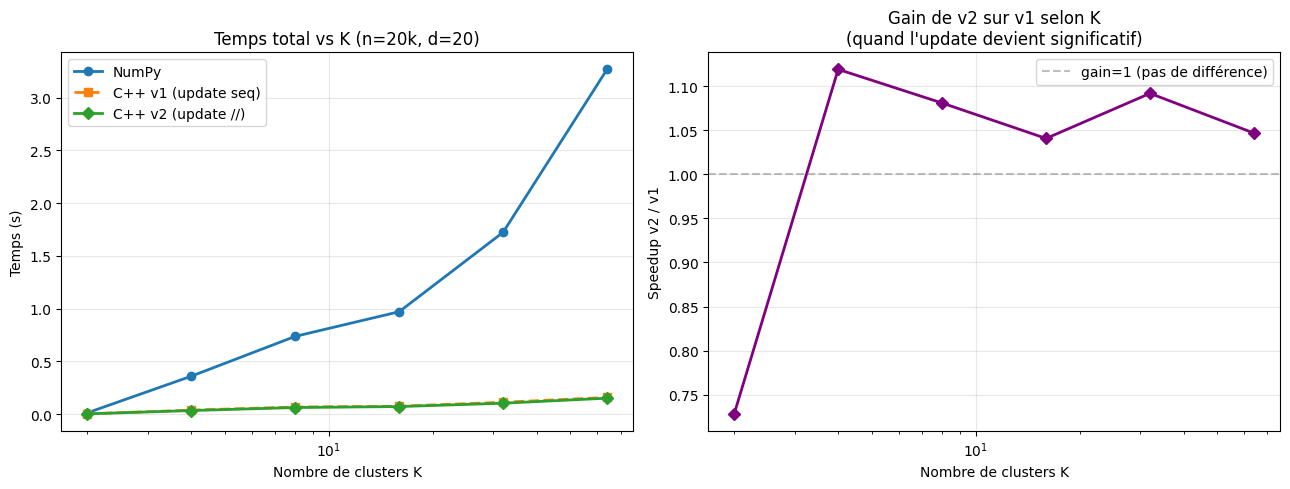

Figure sauvegardée


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogx(df_K["K"], df_K["numpy"], "o-",  label="NumPy",  linewidth=2)
ax.semilogx(df_K["K"], df_K["v1"],    "s--", label="C++ v1 (update seq)", linewidth=2)
ax.semilogx(df_K["K"], df_K["v2"],    "D-",  label="C++ v2 (update //)",  linewidth=2)
ax.set_xlabel("Nombre de clusters K")
ax.set_ylabel("Temps (s)")
ax.set_title("Temps total vs K (n=20k, d=20)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogx(df_K["K"], df_K["gain_v2_vs_v1"], "D-", color="purple", linewidth=2)
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5, label="gain=1 (pas de différence)")
ax.set_xlabel("Nombre de clusters K")
ax.set_ylabel("Speedup v2 / v1")
ax.set_title("Gain de v2 sur v1 selon K\n(quand l'update devient significatif)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../notebooks/fig_further_work_K.png", dpi=120)
plt.show()
print("Figure sauvegardée")